# Ejercicio 4 – Análisis exploratorio con DuckDB

En este notebook se analizan los viajes de taxis amarillos (*yellow*) y verdes (*green*) de 2026 con consultas SQL ejecutadas por DuckDB **directamente sobre los archivos Parquet**.

## Preparación

Para no repetir en cada consulta la unión de ambos tipos de taxi y los filtros de calidad, se define la vista `viajes` (`sql/04_eda/00_vista_viajes.sql`). Una vista es una consulta guardada con nombre, no copia datos, y cada vez que se usa vuelve a leer los Parquet. La vista aplica las decisiones del Ejercicio 3:

- renombra `tpep_*`/`lpep_*` a `pickup_datetime`/`dropoff_datetime` y agrega la columna `tipo`;
- agrega `periodo` (mes del archivo) y `duracion_min`;
- excluye viajes con inicio fuera del mes del archivo, fin anterior o igual al inicio, duración mayor a 24 h, distancia igual a 0 o mayor a 100 millas, y total negativo.

La conexión se configura con `memory_limit = 1GB` y `threads = 2` para que DuckDB no exceda la memoria disponible del equipo; cuando necesita más memoria, escribe resultados intermedios en disco. Por la misma razón, los percentiles se calculan con `approx_quantile`, que usa memoria constante y da resultados aproximados.

## Preguntas de análisis

Las preguntas se plantean a partir de las columnas disponibles (fechas, distancia, tarifa, forma de pago y montos) y de los problemas de calidad encontrados en el Ejercicio 3:

| # | Pregunta | Aspecto | Justificación |
|---|----------|---------|---------------|
| P0 | ¿Cuántos registros conserva la vista después de los filtros? | Calidad | Valida que los filtros no eliminen una parte importante de los datos. |
| P1 | ¿Cómo cambia la cantidad de viajes de un mes a otro? | Temporal | Cada archivo es un mes; permite ver la estacionalidad. |
| P2 | ¿En qué horas y días de la semana se concentran los viajes? | Temporal | Las fechas de inicio permiten identificar patrones de demanda. |
| P3 | ¿Cuál es la distancia, duración y velocidad típica de un viaje? | Características | Describe el viaje típico de cada tipo de taxi. |
| P4 | ¿Qué tipos de tarifa usa cada tipo de taxi? | Diferencias | `RatecodeID` distingue viajes estándar, a aeropuertos y negociados. |
| P5 | ¿Cómo pagan los usuarios y cambia por mes? | Pago | En el Ejercicio 3 se detectó que *Flex Fare* y los pagos nulos concentran los valores faltantes. |
| P6 | ¿Cuánta propina se deja según la forma de pago? | Pago | `tip_amount` es la única parte del cobro que decide el usuario. |
| P7 | ¿Cómo se distribuye el total cobrado y de qué se compone? | Distribución | Los montos tienen muchos componentes (tarifa, recargos, peajes, propina). |
| P8 | ¿Qué valores atípicos o inconsistencias permanecen después de los filtros? | Atípicos | Los filtros solo eliminan valores imposibles; pueden quedar casos poco comunes. |

Las consultas están en `sql/04_eda/`. Cada archivo indica en su comentario inicial la pregunta que responde y su fuente; la función `consulta()` imprime el SQL antes de ejecutarlo.

In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Se trabaja desde la raiz del proyecto para que las rutas data/raw/... funcionen
if Path.cwd().name == "notebooks":
    os.chdir("..")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DIR_SQL = Path("sql/04_eda")
COLORES = {"yellow": "#E0A800", "green": "#2E8B57"}

# Limites de recursos para equipos con poca RAM
con = duckdb.connect(config={"memory_limit": "1GB", "threads": 2, "preserve_insertion_order": False})


def consulta(nombre: str) -> pd.DataFrame | None:
    """Muestra y ejecuta un archivo SQL de DIR_SQL; devuelve el resultado como DataFrame (None si no hay resultado)."""
    sql = (DIR_SQL / nombre).read_text()
    print(sql)
    resultado = con.sql(sql)
    return resultado.df() if resultado is not None else None


consulta("00_vista_viajes.sql")

-- Vista `viajes`: taxis amarillos y verdes unificados y filtrados.
-- Fuente: data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet (todos los anios descargados).
-- Lee los Parquet en cada consulta; no materializa datos.
--
-- Columnas: nombres comunes en snake_case, `tipo` ('yellow' | 'green'), `periodo` (mes del
-- archivo, 'AAAA-MM') y `duracion_min`. `airport_fee` solo existe en yellow y `trip_type` en green.
--
-- Filtros aplicados (ver notebooks/03_exploracion.ipynb):
--   - inicio del viaje dentro del mes del archivo;
--   - fin posterior al inicio y duracion <= 24 h;
--   - distancia > 0 y <= 100 millas;
--   - total_amount >= 0.
CREATE OR REPLACE VIEW viajes AS
WITH unificado AS (
    SELECT
        'yellow'                AS tipo,
        filename,
        VendorID                AS vendor_id,
        tpep_pickup_datetime    AS pickup_datetime,
        tpep_dropoff_datetime   AS dropoff_datetime,
        passenger_count,
        trip_distance,
        RatecodeID         

## P0. ¿Cuántos registros conserva la vista?

Consulta: `01_registros_filtrados.sql`. Compara el número de filas de los metadatos de los Parquet con las filas de la vista.

In [2]:
consulta("01_registros_filtrados.sql")

-- P0 - Registros conservados por la vista `viajes` frente al total de los archivos.
-- Fuente: data/raw/*/*/*.parquet (metadatos) y vista `viajes`.
WITH originales AS (
    SELECT split_part(file_name, '/', 3) AS tipo, sum(num_rows) AS registros_originales
    FROM parquet_file_metadata('data/raw/*/*/*.parquet')
    GROUP BY tipo
),
conservados AS (
    SELECT tipo, count(*) AS registros_conservados
    FROM viajes
    GROUP BY tipo
)
SELECT
    tipo,
    registros_originales,
    registros_conservados,
    registros_originales - registros_conservados                          AS registros_excluidos,
    round(100.0 * registros_conservados / registros_originales, 2)        AS pct_conservado
FROM originales
JOIN conservados USING (tipo)
ORDER BY tipo;



,tipo,registros_originales,registros_conservados,registros_excluidos,pct_conservado
0,green,337114.0,324160,12954.0,96.16
1,yellow,29703355.0,28242805,1460550.0,95.08


**Resultado:** la vista conserva el **95.08%** de los viajes amarillos (28,242,805) y el **96.16%** de los verdes (324,160). Los filtros excluyen menos del 5% de los registros, principalmente por distancia igual a 0.

## P1. ¿Cómo cambia la cantidad de viajes de un mes a otro?

Consulta: `02_viajes_por_mes.sql`. Como los meses tienen distinto número de días, se compara el **promedio de viajes por día**.

In [3]:
por_mes = consulta("02_viajes_por_mes.sql")
por_mes.pivot(index="periodo", columns="tipo", values="viajes_por_dia")

-- P1 - Viajes por mes y tipo de taxi, con promedio diario.
-- Fuente: vista `viajes`.
SELECT
    periodo,
    tipo,
    count(*)                                                 AS viajes,
    round(count(*) / count(DISTINCT pickup_datetime::DATE), 0) AS viajes_por_dia
FROM viajes
GROUP BY periodo, tipo
ORDER BY tipo, periodo;



tipo,green,yellow
periodo,,
2026-01,1254.0,113483.0
2026-02,1282.0,114700.0
2026-03,1377.0,121426.0
2026-04,1418.0,122522.0
2026-05,1396.0,126245.0
2026-06,1419.0,121592.0
2026-07,1274.0,107983.0
2026-08,1252.0,102082.0


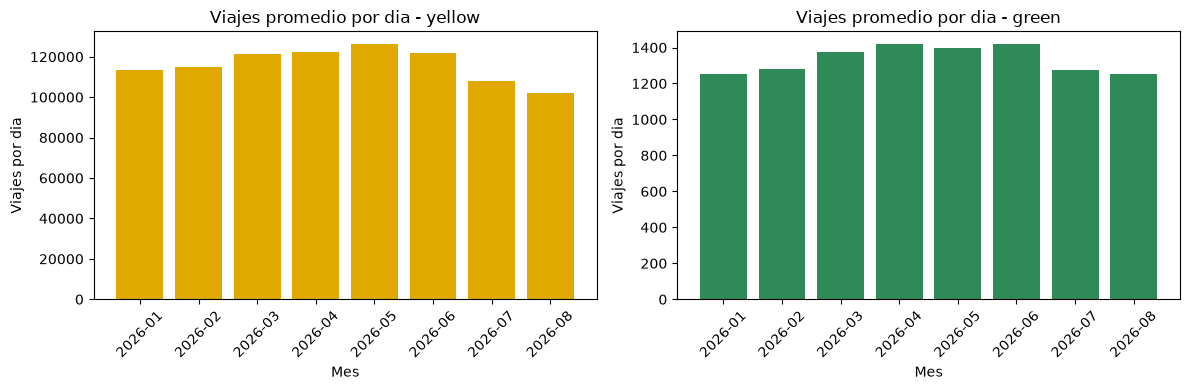

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for eje, tipo in zip(ejes, ["yellow", "green"]):
    datos = por_mes[por_mes["tipo"] == tipo]
    eje.bar(datos["periodo"], datos["viajes_por_dia"], color=COLORES[tipo])
    eje.set_title(f"Viajes promedio por dia - {tipo}")
    eje.set_xlabel("Mes")
    eje.set_ylabel("Viajes por dia")
    eje.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Resultado:**

- Taxis amarillos: los viajes por día suben de 113,483 en enero a un máximo de **126,245 en mayo**, y bajan a **102,082 en agosto** (19% menos que en mayo).
- Taxis verdes: siguen la misma tendencia, con máximo en abril–junio (~1,418 por día) y mínimo en agosto (1,252).

La demanda de ambos tipos de taxi crece en primavera y cae en verano (julio–agosto).

## P2. ¿En qué horas y días se concentran los viajes?

Consulta: `03_viajes_hora_dia.sql`. Se calcula el porcentaje de viajes de cada tipo por hora de inicio y por día de la semana (1 = lunes, 7 = domingo); con porcentajes se pueden comparar ambos tipos aunque tengan volúmenes muy distintos.

In [5]:
hora_dia = consulta("03_viajes_hora_dia.sql")

-- P2 - Porcentaje de los viajes de cada tipo de taxi por dia de la semana y hora de inicio.
-- Fuente: vista `viajes`. dia_semana: 1 = lunes ... 7 = domingo (ISO).
SELECT
    tipo,
    isodow(pickup_datetime)                                        AS dia_semana,
    hour(pickup_datetime)                                          AS hora,
    count(*)                                                       AS viajes,
    100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo)      AS pct_viajes
FROM viajes
GROUP BY tipo, dia_semana, hora
ORDER BY tipo, dia_semana, hora;



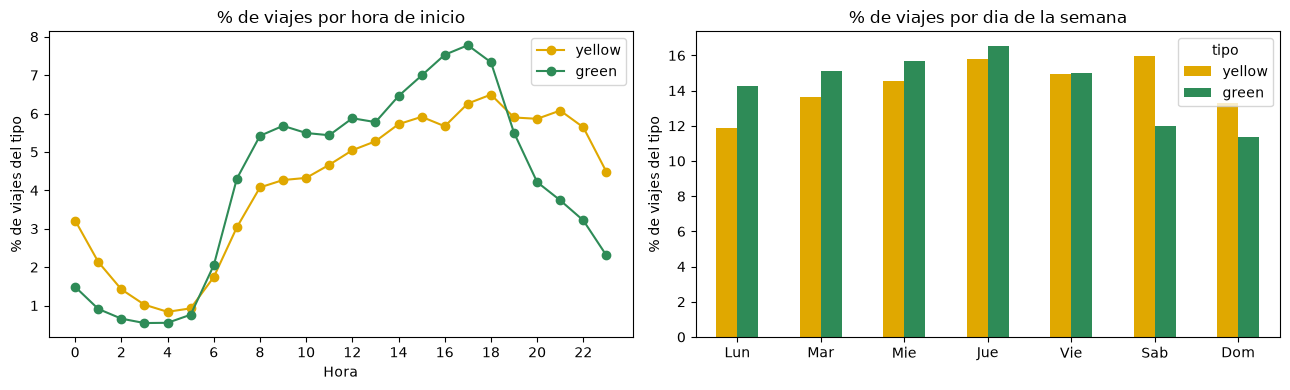

In [6]:
por_hora = hora_dia.pivot_table(index="hora", columns="tipo", values="pct_viajes", aggfunc="sum")
por_dia = hora_dia.pivot_table(index="dia_semana", columns="tipo", values="pct_viajes", aggfunc="sum")
por_dia.index = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
for tipo in ["yellow", "green"]:
    ejes[0].plot(por_hora.index, por_hora[tipo], marker="o", color=COLORES[tipo], label=tipo)
ejes[0].set_title("% de viajes por hora de inicio")
ejes[0].set_xlabel("Hora")
ejes[0].set_ylabel("% de viajes del tipo")
ejes[0].set_xticks(range(0, 24, 2))
ejes[0].legend()
por_dia[["yellow", "green"]].plot.bar(ax=ejes[1], color=[COLORES["yellow"], COLORES["green"]], rot=0)
ejes[1].set_title("% de viajes por dia de la semana")
ejes[1].set_ylabel("% de viajes del tipo")
plt.tight_layout()
plt.show()

In [7]:
por_hora.round(2).T

hora,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
tipo,,,,,,,,,,,,,,,,,,,,,,,,
green,1.49,0.91,0.66,0.54,0.55,0.76,2.05,4.30,5.42,5.68,5.49,5.43,5.88,5.78,6.46,6.99,7.53,7.78,7.33,5.5,4.21,3.74,3.22,2.30
yellow,3.21,2.13,1.42,1.02,0.84,0.93,1.74,3.04,4.08,4.27,4.32,4.66,5.04,5.28,5.72,5.91,5.67,6.26,6.49,5.9,5.86,6.08,5.64,4.48


**Resultado:**

- Ambos tipos tienen su mínimo entre las 3:00 y las 5:00 y su máximo por la tarde: amarillos a las **18:00** (6.49%) y verdes a las **17:00** (7.78%).
- Los **verdes caen rápidamente después de las 18:00** (2.30% a las 23:00), mientras que los **amarillos se mantienen altos hasta las 22:00** (5.64%) y conservan actividad de madrugada (3.21% a medianoche).
- Por día: los verdes se concentran de lunes a jueves (máximo el jueves, 16.54%) y bajan el fin de semana (11–12%). Los amarillos tienen su máximo el **sábado** (15.95%) y su mínimo el lunes (11.89%).

Los taxis verdes siguen un patrón asociado a días laborales y horario diurno; los amarillos tienen más actividad nocturna y de fin de semana.

## P3. ¿Cuál es la distancia, duración y velocidad típica de un viaje?

Consulta: `04_caracteristicas_viaje.sql`. Se calculan los percentiles 25, 50 (mediana), 75 y 99 de cada métrica en un solo recorrido de los datos. La velocidad se obtiene como distancia / duración (millas por hora).

In [8]:
caracteristicas = consulta("04_caracteristicas_viaje.sql")
percentiles = pd.DataFrame(caracteristicas["percentiles"].tolist(), columns=["p25", "mediana", "p75", "p99"])
caracteristicas = pd.concat([caracteristicas[["metrica", "tipo"]], percentiles.round(2)], axis=1)
caracteristicas

-- P3 - Distribucion de distancia, duracion, velocidad y pasajeros por tipo de taxi.
-- Fuente: vista `viajes`. Velocidad en millas por hora; pasajeros excluye nulos.
-- Percentiles aproximados (approx_quantile, t-digest): memoria constante sobre millones de filas.
UNPIVOT (
    SELECT
        tipo,
        approx_quantile(trip_distance, [0.25, 0.5, 0.75, 0.99])                     AS distancia_mi,
        approx_quantile(duracion_min, [0.25, 0.5, 0.75, 0.99])                      AS duracion_min,
        approx_quantile(trip_distance / (duracion_min / 60), [0.25, 0.5, 0.75, 0.99]) AS velocidad_mph,
        approx_quantile(passenger_count, [0.25, 0.5, 0.75, 0.99])                   AS pasajeros
    FROM viajes
    GROUP BY tipo
)
ON distancia_mi, duracion_min, velocidad_mph, pasajeros
INTO NAME metrica VALUE percentiles
ORDER BY metrica, tipo;



,metrica,tipo,p25,mediana,p75,p99
0,distancia_mi,green,1.33,2.15,3.78,17.92
1,distancia_mi,yellow,1.10,1.93,3.96,19.60
2,duracion_min,green,8.69,13.35,20.73,83.31
3,duracion_min,yellow,8.62,14.13,22.27,71.89
4,pasajeros,green,1.00,1.00,1.00,6.00
5,pasajeros,yellow,1.00,1.00,1.00,4.00
6,velocidad_mph,green,7.93,10.04,13.13,34.43
7,velocidad_mph,yellow,6.83,9.28,12.93,34.46


**Resultado:**

- El viaje típico es **corto**: mediana de ~2 millas y ~13–14 minutos en ambos tipos.
- La **velocidad mediana** es de ~9–10 mph, lo que refleja el tráfico de la ciudad.
- La mitad central de los viajes (p25–p75) recorre entre ~1.1 y ~4 millas.
- El percentil 99 de distancia es de ~18–20 millas, que corresponde a viajes largos como los de aeropuerto.
- La mediana de pasajeros es 1 en ambos tipos.

Las características del viaje típico son muy similares entre taxis amarillos y verdes.

## P4. ¿Qué tipos de tarifa usa cada tipo de taxi?

Consulta: `05_tipo_tarifa.sql`. Los códigos de `RatecodeID` se traducen según el diccionario de datos de la TLC.

In [9]:
consulta("05_tipo_tarifa.sql")

-- P4 - Distribucion de viajes por tipo de tarifa (RatecodeID) y tipo de taxi.
-- Fuente: vista `viajes`. Codigos segun el diccionario de datos de la TLC.
SELECT
    tipo,
    CASE ratecode_id
        WHEN 1  THEN '1 Estandar'
        WHEN 2  THEN '2 JFK'
        WHEN 3  THEN '3 Newark'
        WHEN 4  THEN '4 Nassau/Westchester'
        WHEN 5  THEN '5 Negociada'
        WHEN 6  THEN '6 Viaje grupal'
        WHEN 99 THEN '99 Desconocido'
        ELSE 'Nulo'
    END                                                                AS tipo_tarifa,
    count(*)                                                           AS viajes,
    round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS pct_viajes,
    round(avg(total_amount), 2)                                        AS total_promedio
FROM viajes
GROUP BY tipo, tipo_tarifa
ORDER BY tipo, tipo_tarifa;



,tipo,tipo_tarifa,viajes,pct_viajes,total_promedio
0,green,1 Estandar,263063,81.15,22.83
1,green,2 JFK,658,0.20,88.84
2,green,3 Newark,139,0.04,105.30
3,green,4 Nassau/Westchester,345,0.11,114.30
4,green,5 Negociada,12275,3.79,56.92
5,green,6 Viaje grupal,1,0.00,4.00
6,green,Nulo,47679,14.71,30.64
7,yellow,1 Estandar,19473873,68.95,25.91
8,yellow,2 JFK,661064,2.34,94.85
9,yellow,3 Newark,81394,0.29,103.42


**Resultado:**

| Tipo de tarifa | yellow | green |
|----------------|---------:|--------:|
| Estándar | 68.95% | 81.15% |
| JFK | 2.34% | 0.20% |
| Newark | 0.29% | 0.04% |
| Negociada | 0.55% | 3.79% |
| Desconocido (99) | 2.70% | — |
| Nulo | 24.94% | 14.71% |

- Los viajes al aeropuerto JFK son **10 veces más frecuentes** en los taxis amarillos, con un total promedio de 94.85 USD.
- La tarifa negociada es casi **7 veces más frecuente** en los taxis verdes.
- La categoría nula corresponde a los viajes *Flex Fare* (yellow) y sin forma de pago (green) identificados en el Ejercicio 3.

## P5. ¿Cómo pagan los usuarios y cambia por mes?

Consulta: `06_forma_pago.sql`. Se calcula el porcentaje de viajes de cada forma de pago por tipo de taxi y mes.

In [10]:
pagos = consulta("06_forma_pago.sql")
pagos.pivot_table(index=["tipo", "forma_pago"], columns="periodo", values="pct_viajes")

-- P5 - Forma de pago por tipo de taxi y mes (porcentaje de viajes).
-- Fuente: vista `viajes`. Codigos segun el diccionario de datos de la TLC.
SELECT
    tipo,
    periodo,
    CASE payment_type
        WHEN 0 THEN '0 Flex Fare'
        WHEN 1 THEN '1 Tarjeta'
        WHEN 2 THEN '2 Efectivo'
        WHEN 3 THEN '3 Sin cargo'
        WHEN 4 THEN '4 Disputa'
        WHEN 5 THEN '5 Desconocido'
        WHEN 6 THEN '6 Anulado'
        ELSE 'Nulo'
    END                                                                            AS forma_pago,
    count(*)                                                                       AS viajes,
    round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo, periodo), 2)   AS pct_viajes
FROM viajes
GROUP BY tipo, periodo, forma_pago
ORDER BY tipo, periodo, forma_pago;



periodo               2026-01  2026-02  2026-03  2026-04  2026-05  2026-06  2026-07  2026-08
tipo   forma_pago                                                                           
green  1 Tarjeta        65.28    64.84    64.92    66.01    67.02    65.68    65.76    64.60
       2 Efectivo       20.59    19.98    19.28    19.03    19.71    19.01    18.19    19.62
       3 Sin cargo       0.28     0.30     0.25     0.23     0.20     0.23     0.22     0.22
       4 Disputa         0.10     0.14     0.09     0.10     0.09     0.10     0.11     0.09
       Nulo             13.75    14.74    15.46    14.63    12.99    14.98    15.72    15.47
yellow 0 Flex Fare      28.29    28.93    22.85    20.15    22.47    25.30    26.24    26.52
       1 Tarjeta        62.34    62.29    67.65    70.00    68.01    64.91    63.44    63.05
       2 Efectivo        8.33     7.97     8.88     9.34     9.04     9.30     9.81     9.89
       3 Sin cargo       0.26     0.21     0.20     0.20     0.18     0.18     0.19     0.19
       4 Disputa         0.79     0.60     0.42     0.32     0.30     0.31     0.33     0.34
       5 Desconocido      NaN      NaN      NaN      NaN      NaN     0.00      NaN      NaN

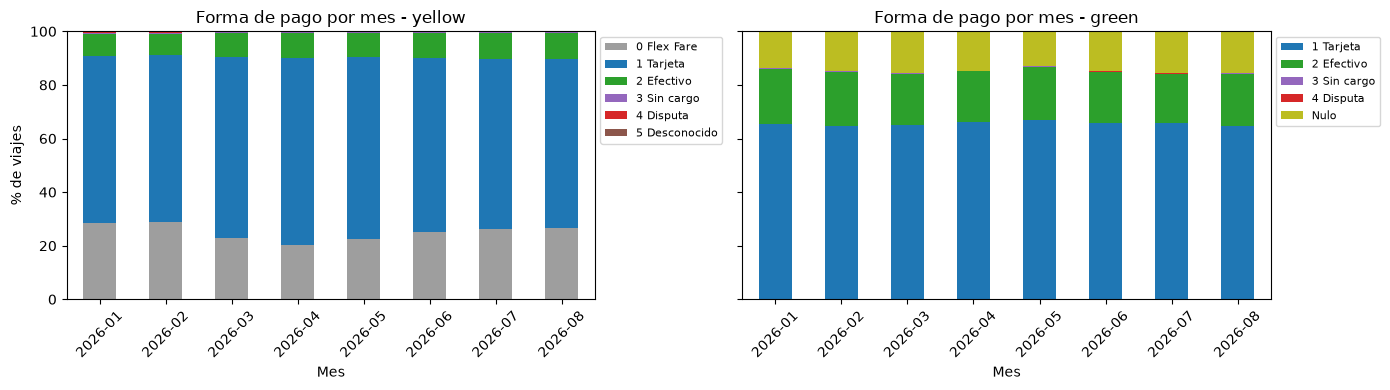

In [11]:
COLORES_PAGO = {
    "0 Flex Fare": "#9E9E9E", "1 Tarjeta": "#1F77B4", "2 Efectivo": "#2CA02C", "3 Sin cargo": "#9467BD",
    "4 Disputa": "#D62728", "5 Desconocido": "#8C564B", "Nulo": "#BCBD22",
}
fig, ejes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for eje, tipo in zip(ejes, ["yellow", "green"]):
    tabla = pagos[pagos["tipo"] == tipo].pivot_table(index="periodo", columns="forma_pago", values="pct_viajes", fill_value=0)
    tabla.plot.bar(stacked=True, ax=eje, rot=45, color=[COLORES_PAGO[c] for c in tabla.columns])
    eje.set_title(f"Forma de pago por mes - {tipo}")
    eje.set_xlabel("Mes")
    eje.set_ylabel("% de viajes")
    eje.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

**Resultado:**

- **Tarjeta** es la forma de pago principal: 62–70% en amarillos y 65–67% en verdes.
- El **efectivo** es más del doble de frecuente en los verdes (18–21%) que en los amarillos (8–10%).
- *Flex Fare* (solo amarillos) varía entre **20.15% (abril) y 28.93% (febrero)**: cuando baja, sube el pago con tarjeta. Los verdes con forma de pago nula se mantienen entre 13% y 16%.
- Las disputas en amarillos bajan de 0.79% en enero a ~0.3% desde abril.

## P6. ¿Cuánta propina se deja según la forma de pago?

Consulta: `07_propinas.sql`. Para cada forma de pago se calcula el porcentaje de viajes con propina, la propina promedio y la mediana de la propina como porcentaje de la tarifa (solo en viajes con propina).

In [12]:
consulta("07_propinas.sql")

-- P6 - Propina segun forma de pago y tipo de taxi.
-- Fuente: vista `viajes`. pct_propina = tip_amount / fare_amount (solo viajes con fare_amount > 0).
-- Mediana aproximada (approx_quantile).
SELECT
    tipo,
    CASE payment_type
        WHEN 0 THEN '0 Flex Fare'
        WHEN 1 THEN '1 Tarjeta'
        WHEN 2 THEN '2 Efectivo'
        WHEN 3 THEN '3 Sin cargo'
        WHEN 4 THEN '4 Disputa'
        ELSE 'Otro / Nulo'
    END                                                                       AS forma_pago,
    count(*)                                                                  AS viajes,
    round(100.0 * count(*) FILTER (WHERE tip_amount > 0) / count(*), 2)       AS pct_con_propina,
    round(avg(tip_amount), 2)                                                 AS propina_promedio,
    round(100 * approx_quantile(tip_amount / fare_amount, 0.5) FILTER (WHERE tip_amount > 0), 2) AS mediana_pct_propina_si_hay
FROM viajes
WHERE fare_amount > 0
GROUP BY tipo, forma_pago
ORDER BY 

,tipo,forma_pago,viajes,pct_con_propina,propina_promedio,mediana_pct_propina_si_hay
0,green,1 Tarjeta,212456,91.34,3.81,24.24
1,green,2 Efectivo,62879,0.00,0.00,NaN
2,green,3 Sin cargo,723,0.28,0.01,32.98
3,green,4 Disputa,273,0.00,0.00,NaN
4,green,Otro / Nulo,43034,17.11,0.84,20.77
5,yellow,0 Flex Fare,7036916,8.28,0.40,21.55
6,yellow,1 Tarjeta,18460906,91.12,4.26,27.22
7,yellow,2 Efectivo,2556893,0.01,0.00,27.61
8,yellow,3 Sin cargo,56295,0.02,0.00,30.72
9,yellow,4 Disputa,118037,0.03,0.00,21.93


**Resultado:**

- Con **tarjeta**, el 91% de los viajes registra propina, con una mediana de **~27% (yellow) y ~24% (green)** de la tarifa.
- Con **efectivo**, prácticamente ningún viaje registra propina (0.00–0.01%). Esto no significa que no se deje propina, sino que probablemente las propinas en efectivo no quedan registradas en los datos.

Por lo tanto, el análisis de propinas solo es confiable en los viajes pagados con tarjeta.

## P7. ¿Cómo se distribuye el total cobrado y de qué se compone?

Consultas: `08_distribucion_montos.sql` (promedio de cada componente del cobro) y `08_histograma_total.sql` (porcentaje de viajes por intervalos de 5 USD de `total_amount`).

In [13]:
consulta("08_distribucion_montos.sql").pivot(index="componente", columns="tipo", values="promedio").round(2).sort_values("yellow", ascending=False)

-- P7 - Distribucion (percentiles) del total cobrado y de sus componentes por tipo de taxi.
-- Fuente: vista `viajes`.
UNPIVOT (
    SELECT
        tipo,
        avg(fare_amount)            AS fare_amount,
        avg(extra)                  AS extra,
        avg(mta_tax)                AS mta_tax,
        avg(tip_amount)             AS tip_amount,
        avg(tolls_amount)           AS tolls_amount,
        avg(improvement_surcharge)  AS improvement_surcharge,
        avg(coalesce(congestion_surcharge, 0)) AS congestion_surcharge,
        avg(coalesce(airport_fee, 0))          AS airport_fee,
        avg(cbd_congestion_fee)     AS cbd_congestion_fee,
        avg(total_amount)           AS total_amount
    FROM viajes
    GROUP BY tipo
)
ON COLUMNS(* EXCLUDE (tipo))
INTO NAME componente VALUE promedio
ORDER BY tipo, promedio DESC;



tipo,green,yellow
componente,,
total_amount,25.53,30.24
fare_amount,16.91,21.29
tip_amount,2.61,2.88
congestion_surcharge,0.78,1.69
extra,0.83,1.17
improvement_surcharge,0.92,0.98
tolls_amount,0.30,0.55
cbd_congestion_fee,0.06,0.54
mta_tax,0.56,0.50


-- P7 - Histograma del total cobrado (intervalos de 5 USD hasta 150 USD) por tipo de taxi.
-- Fuente: vista `viajes`. Valores > 150 se agrupan en el ultimo intervalo.
SELECT
    tipo,
    least(floor(total_amount / 5) * 5, 150)                         AS intervalo_desde,
    count(*)                                                        AS viajes,
    100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo)       AS pct_viajes
FROM viajes
GROUP BY tipo, intervalo_desde
ORDER BY tipo, intervalo_desde;



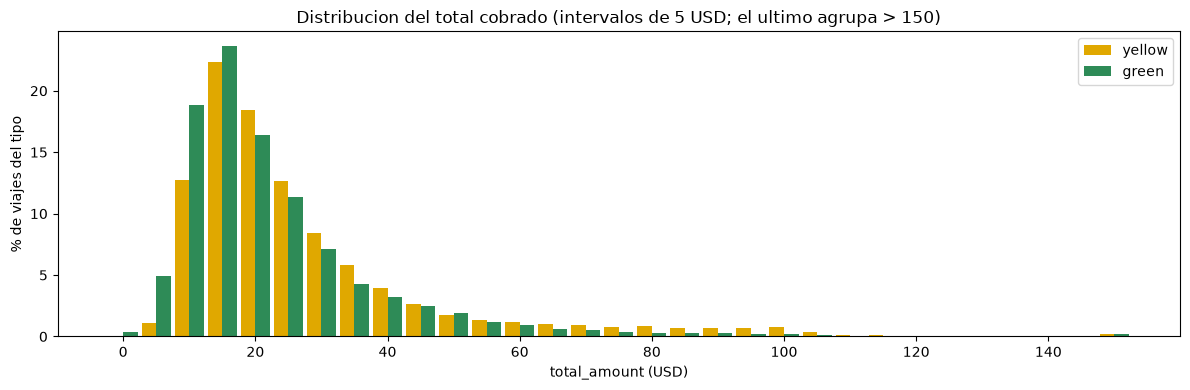

In [14]:
histograma = consulta("08_histograma_total.sql")
tabla = histograma.pivot(index="intervalo_desde", columns="tipo", values="pct_viajes").fillna(0)

fig, eje = plt.subplots(figsize=(12, 4))
ancho = 2.2
eje.bar(tabla.index - ancho / 2, tabla["yellow"], width=ancho, color=COLORES["yellow"], label="yellow")
eje.bar(tabla.index + ancho / 2, tabla["green"], width=ancho, color=COLORES["green"], label="green")
eje.set_title("Distribucion del total cobrado (intervalos de 5 USD; el ultimo agrupa > 150)")
eje.set_xlabel("total_amount (USD)")
eje.set_ylabel("% de viajes del tipo")
eje.legend()
plt.tight_layout()
plt.show()

**Resultado:**

- El total promedio es **30.24 USD en amarillos** y **25.53 USD en verdes**. La tarifa base (`fare_amount`) es el componente principal (21.29 y 16.91 USD).
- El recargo por congestión (1.69 vs 0.78 USD) y el `cbd_congestion_fee` (0.54 vs 0.06 USD) son mucho mayores en los amarillos, porque estos recargos se cobran en viajes por Manhattan, donde operan principalmente los taxis amarillos.
- La distribución es **asimétrica a la derecha**: el intervalo más frecuente es 15–20 USD en ambos tipos (22.37% y 23.66%), con una cola larga de viajes caros.
- Los verdes tienen más viajes baratos (5–15 USD: 23.8% vs 13.9%). Los amarillos tienen un grupo de viajes entre 70 y 105 USD, que coincide con las tarifas de aeropuerto (P4).

## P8. ¿Qué valores atípicos o inconsistencias permanecen?

Consultas:

- `09_atipicos.sql`: cuenta viajes con condiciones poco comunes. Un total es atípico según la regla IQR si supera Q3 + 1.5 × (Q3 − Q1).
- `10_total_no_cuadra.sql`: compara `total_amount` con la suma de sus componentes por forma de pago.

In [15]:
consulta("09_atipicos.sql").set_index("tipo").T

-- P8 - Valores atipicos e inconsistencias que permanecen en la vista `viajes`.
-- Fuente: vista `viajes`.
-- Atipico de total_amount segun regla IQR: > Q3 + 1.5 * (Q3 - Q1), calculado por tipo de taxi.
-- Cuartiles aproximados (approx_quantile).
WITH limites AS (
    SELECT
        tipo,
        approx_quantile(total_amount, 0.75)
            + 1.5 * (approx_quantile(total_amount, 0.75) - approx_quantile(total_amount, 0.25)) AS limite_iqr_total
    FROM viajes
    GROUP BY tipo
)
SELECT
    v.tipo,
    count(*)                                                                         AS viajes,
    round(any_value(l.limite_iqr_total), 2)                                          AS limite_iqr_total,
    count(*) FILTER (WHERE v.total_amount > l.limite_iqr_total)                      AS total_atipico_iqr,
    count(*) FILTER (WHERE v.trip_distance / (v.duracion_min / 60) > 80)             AS velocidad_mayor_80mph,
    count(*) FILTER (WHERE v.duracion_min < 1)                             

tipo,green,yellow
viajes,324160.00,28242805.00
limite_iqr_total,51.57,59.96
total_atipico_iqr,21584.00,2409588.00
velocidad_mayor_80mph,1087.00,7210.00
duracion_menor_1min,3487.00,87686.00
total_cero,490.00,2576.00
propina_mayor_tarifa,578.00,28726.00
total_no_cuadra,65117.00,10089716.00


In [16]:
consulta("10_total_no_cuadra.sql")

-- P8 - Diferencia entre total_amount y la suma de sus componentes, por tipo de taxi y forma de pago.
-- Fuente: vista `viajes`. diferencia = total_amount - suma de componentes; "no cuadra" si |diferencia| > 0.01.
-- Mediana aproximada (approx_quantile).
WITH diferencias AS (
    SELECT
        tipo,
        payment_type,
        total_amount - (fare_amount + extra + mta_tax + tip_amount + tolls_amount + improvement_surcharge
                        + coalesce(congestion_surcharge, 0) + coalesce(airport_fee, 0) + cbd_congestion_fee) AS diferencia
    FROM viajes
)
SELECT
    tipo,
    payment_type,
    count(*)                                                                   AS viajes,
    count(*) FILTER (WHERE abs(diferencia) > 0.01)                             AS no_cuadra,
    round(100.0 * count(*) FILTER (WHERE abs(diferencia) > 0.01) / count(*), 2) AS pct_no_cuadra,
    round(approx_quantile(diferencia, 0.5) FILTER (WHERE abs(diferencia) > 0.01), 2) AS mediana_diferencia
FROM d

,tipo,payment_type,viajes,no_cuadra,pct_no_cuadra,mediana_diferencia
0,green,1,212457,20414,9.61,-1.00
1,green,2,62921,5080,8.07,-1.00
2,green,3,774,360,46.51,-1.00
3,green,4,329,95,28.88,-1.00
4,green,<NA>,47679,39168,82.15,19.64
5,yellow,0,7044930,6300608,89.43,2.50
6,yellow,1,18461002,3310771,17.93,-3.25
7,yellow,2,2560875,416511,16.26,-3.25
8,yellow,3,56939,39136,68.73,-3.25
9,yellow,4,119058,22690,19.06,-3.25


**Resultado:**

| Condición | Yellow | % | Green | % |
|-----------|-------:|--:|------:|--:|
| Total atípico (IQR; límite ≈ 60 USD yellow, ≈ 52 USD green) | ≈ 2.41 M | ≈ 8.5 | ≈ 21.6 mil | ≈ 6.7 |
| Velocidad > 80 mph | 7,210 | 0.03 | 1,087 | 0.34 |
| Duración < 1 minuto | 87,686 | 0.31 | 3,487 | 1.08 |
| Total = 0 | 2,576 | 0.01 | 490 | 0.15 |
| Propina mayor que la tarifa | 28,726 | 0.10 | 578 | 0.18 |
| Total no cuadra con sus componentes | 10,089,716 | 35.73 | 65,117 | 20.09 |

- Los conteos IQR son aproximados (dependen de `approx_quantile`) y pueden variar levemente entre ejecuciones. Los totales atípicos (~7–9%) son en su mayoría **viajes largos o al aeropuerto**, no errores. La regla IQR marca la cola larga de la distribución vista en P7.
- Las velocidades mayores a 80 mph y los viajes de menos de un minuto con distancia positiva son **físicamente improbables** y son proporcionalmente más frecuentes en los verdes.
- El **total no cuadra** con la suma de sus componentes en más de un tercio de los viajes amarillos:
  - en *Flex Fare* (yellow) y pago nulo (green) el total es **mayor** que la suma (mediana +2.50 y +19.64 USD): los componentes están incompletos;
  - en tarjeta y efectivo el total es **menor** que la suma: 3.25 USD en amarillos (= 2.50 de congestión + 0.75 de CBD) y 1.00 USD en verdes, lo que indica que en parte de los viajes esos recargos también se registran dentro de `extra`.

Para analizar montos se debe usar `total_amount` y no recalcularlo sumando sus componentes.

## Hallazgos principales

1. **Patrones de uso distintos.** Los taxis verdes concentran sus viajes en días laborales y horario diurno (máximo a las 17:00, caída rápida después de las 18:00). Los amarillos tienen más actividad nocturna y su día con más viajes es el sábado.
2. **Estacionalidad.** La demanda de ambos tipos crece hasta mayo–junio y cae en julio–agosto; en los amarillos, agosto tiene 19% menos viajes por día que mayo.
3. **Diferencias en tarifa y pago.** Los amarillos hacen 10 veces más viajes a JFK y tienen un total promedio mayor (30.24 vs 25.53 USD). Los verdes usan más la tarifa negociada (3.79%) y el efectivo (~20%).
4. **Las propinas solo se registran con tarjeta.** El 91% de los viajes con tarjeta tiene propina (mediana ~25% de la tarifa), mientras que con efectivo prácticamente ninguno la registra.
5. **Inconsistencias en los montos.** Entre el 20% y el 29% de los viajes amarillos de cada mes (*Flex Fare*) y entre el 13% y el 16% de los verdes (pago nulo) no tienen pasajeros, tipo de tarifa ni desglose completo. Además, en más de un tercio de los viajes amarillos el total no coincide con la suma de sus componentes.